In [1]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
from pathlib import Path
import torch
from torch.utils.data import DataLoader, Subset
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed
from src.utils.experiment_utils import find_experiment_by_name

# Importar as funções
from src.result_analysis.plots import ( plot_predictions_with_context,)

from src.result_analysis.metrics import (compute_flow_metrics,print_metrics_summary)

from src import ConfigLoader, load_config

from src import save_predictions, save_plot
from src.utils.experiment_utils import convert_predictions_to_df

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed_inference"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed_inference


In [2]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

experiment_name = data_config["experiment_name"]
stations = data_config["stations"]


⚙️ Carregando configurações...


### Importação de OBS

In [3]:
pasta = Path(r"C:/Users/emily/Documents/Dados_previsao_operacao/dados_previsoes_passadas/operacao_2026_03_23")

def carregar_series_completas():
    dados = {}
    
    for arquivo in pasta.glob("*_complete_date_inference.csv"):
        
        estacao = arquivo.name.split("_")[0]
        
        try:
            df = pd.read_csv(
                arquivo,
                parse_dates=['date']
            )
        except Exception as e:
            print(f"Erro ao ler {arquivo.name}: {e}")
            continue
        
        if df.empty:
            print(f"Aviso: {arquivo.name} está vazio.")
            continue
        
        df = df.sort_values('date').reset_index(drop=True)
        
        dados[estacao] = df
        
        print(f"Estação {estacao}: {len(df)} registros carregados.")
    
    return dados

In [4]:
dados_historicos = carregar_series_completas()

Estação 10100000: 36 registros carregados.
Estação 14100000: 36 registros carregados.


### Importação de todas as preds

In [5]:
import os
import pandas as pd

base_path = r"C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments"
csv_relative_path = os.path.join("predictions_operational", "raw", "prediction_2026_03_17.csv")

experiments = {}

# Lista todas as subpastas dentro de experiments
subfolders = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f)) and f.startswith("exp_")])

for folder in subfolders:
    # Extrai o número do experimento (ex: "exp_002")
    exp_key = "_".join(folder.split("_")[:2])  # pega "exp_002"
    
    csv_path = os.path.join(base_path, folder, csv_relative_path)

    if not os.path.exists(csv_path):
        print(f"CSV não encontrado no experimento: {folder}")
        continue

    experiments[exp_key] = pd.read_csv(csv_path, sep=",")
    print(f"{exp_key} ({folder}) carregado! ({len(experiments[exp_key])} linhas)")

print(f"\nTotal de experimentos carregados: {len(experiments)}")
print(f"Chaves disponíveis: {list(experiments.keys())}")

exp_000 (exp_000_Operational_Framework_no_loss_direction) carregado! (15 linhas)
CSV não encontrado no experimento: exp_001_Improve_model_performance_no_loss_direction
exp_002 (exp_002_Improve_model_performance_adjustment_training_losses) carregado! (15 linhas)
exp_003 (exp_003_Improve_model_performance_adjustment_freerun_gatemax) carregado! (15 linhas)
exp_004 (exp_004_Improve_model_performance_adjustment_direction_slope) carregado! (15 linhas)
exp_005 (exp_005_Improve_model_performance_adjustment_architecture_remove_ypred_MLP_for_climate) carregado! (15 linhas)
exp_006 (exp_006_Improve_model_performance_no_gate_climate_skip) carregado! (15 linhas)
CSV não encontrado no experimento: exp_007_Improve_model_performance_anchored_prediction
exp_008 (exp_008_Improve_model_performance_anchored_high_direction) carregado! (15 linhas)
exp_009 (exp_009_Improve_model_performance_autoregressive_climate_skip_gate) carregado! (15 linhas)
CSV não encontrado no experimento: exp_010_Improve_model_perfo

Info experimentos nao encontrados

exp 001, ajuste na loss

exp_007, anchored (sem melhora) - SERIA BOM OBTER

exp_010, apenas diagnostico

exp_012 fx em climate_proj_fix_no_flow - SERIA BOM OBTER

exp_015 REPETIDO

exp_018 REPETIDO 

### Plots

In [6]:
def plot_operacional_all_experiments(dados_historicos, experiments, stations):

    # ── 1. PRÉ-CALCULA ylim por estação ──
    ylims = {}
    for st in stations:
        col_pred = f'Q_pred_{st}'
        all_values = []

        if str(st) in dados_historicos:                          # <-- str(st)
            df_obs_all = dados_historicos[str(st)].copy()        # <-- str(st)
            df_obs_all['date'] = pd.to_datetime(df_obs_all['date'])
            all_values.extend(df_obs_all['mean_Q'].dropna().tolist())

        for df_pred_full in experiments.values():
            if col_pred in df_pred_full.columns:
                all_values.extend(df_pred_full[col_pred].dropna().tolist())

        if all_values:
            margin = (max(all_values) - min(all_values)) * 0.05
            ylims[st] = (min(all_values) - margin, max(all_values) + margin)

    # ── 2. LOOP DE PLOTS ──
    for exp_key, df_pred_full in experiments.items():

        fig, axes = plt.subplots(len(stations), 1, figsize=(16, 4 * len(stations)), sharex=False)
        if len(stations) == 1:
            axes = [axes]

        fig.suptitle(f'Experimento: {exp_key} — Observado vs Previsão',
                     fontsize=14, fontweight='bold', y=1.01)

        for ax, st in zip(axes, stations):

            col_pred = f'Q_pred_{st}'

            if col_pred not in df_pred_full.columns:
                ax.set_title(f'Estação {st} — coluna {col_pred} não encontrada', fontsize=11)
                ax.axis('off')
                continue

            # ── Previsto ──
            df_pred = df_pred_full[['date', col_pred]].copy()
            df_pred['date'] = pd.to_datetime(df_pred['date'])
            df_pred = df_pred.sort_values('date')
            forecast_start = df_pred['date'].min()

            # ── Observado ──
            has_obs = str(st) in dados_historicos                # <-- str(st)

            if has_obs:
                df_obs = dados_historicos[str(st)].copy()        # <-- str(st)
                df_obs['date'] = pd.to_datetime(df_obs['date'])
                df_obs = df_obs.sort_values('date')

                cutoff = forecast_start - pd.Timedelta(days=60)
                df_obs_plot = df_obs[df_obs['date'] >= cutoff]

                ax.plot(df_obs_plot['date'], df_obs_plot['mean_Q'],
                        label='Observado', color='black', linewidth=2)

            ax.plot(df_pred['date'], df_pred[col_pred],
                    label='Previsto', color='royalblue', linestyle='--', linewidth=2)

            ax.axvline(forecast_start, color='red', linestyle='--',
                       linewidth=1.5, label='Início da previsão')

            if st in ylims:
                ax.set_ylim(ylims[st])

            titulo = f'Estação {st}' + ('' if has_obs else ' (sem dados observados)')
            ax.set_title(titulo, fontsize=11, fontweight='bold')
            ax.set_xlabel('Data')
            ax.set_ylabel('Vazão (m³/s)')
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            ax.legend()

        plt.tight_layout()
        plt.show()

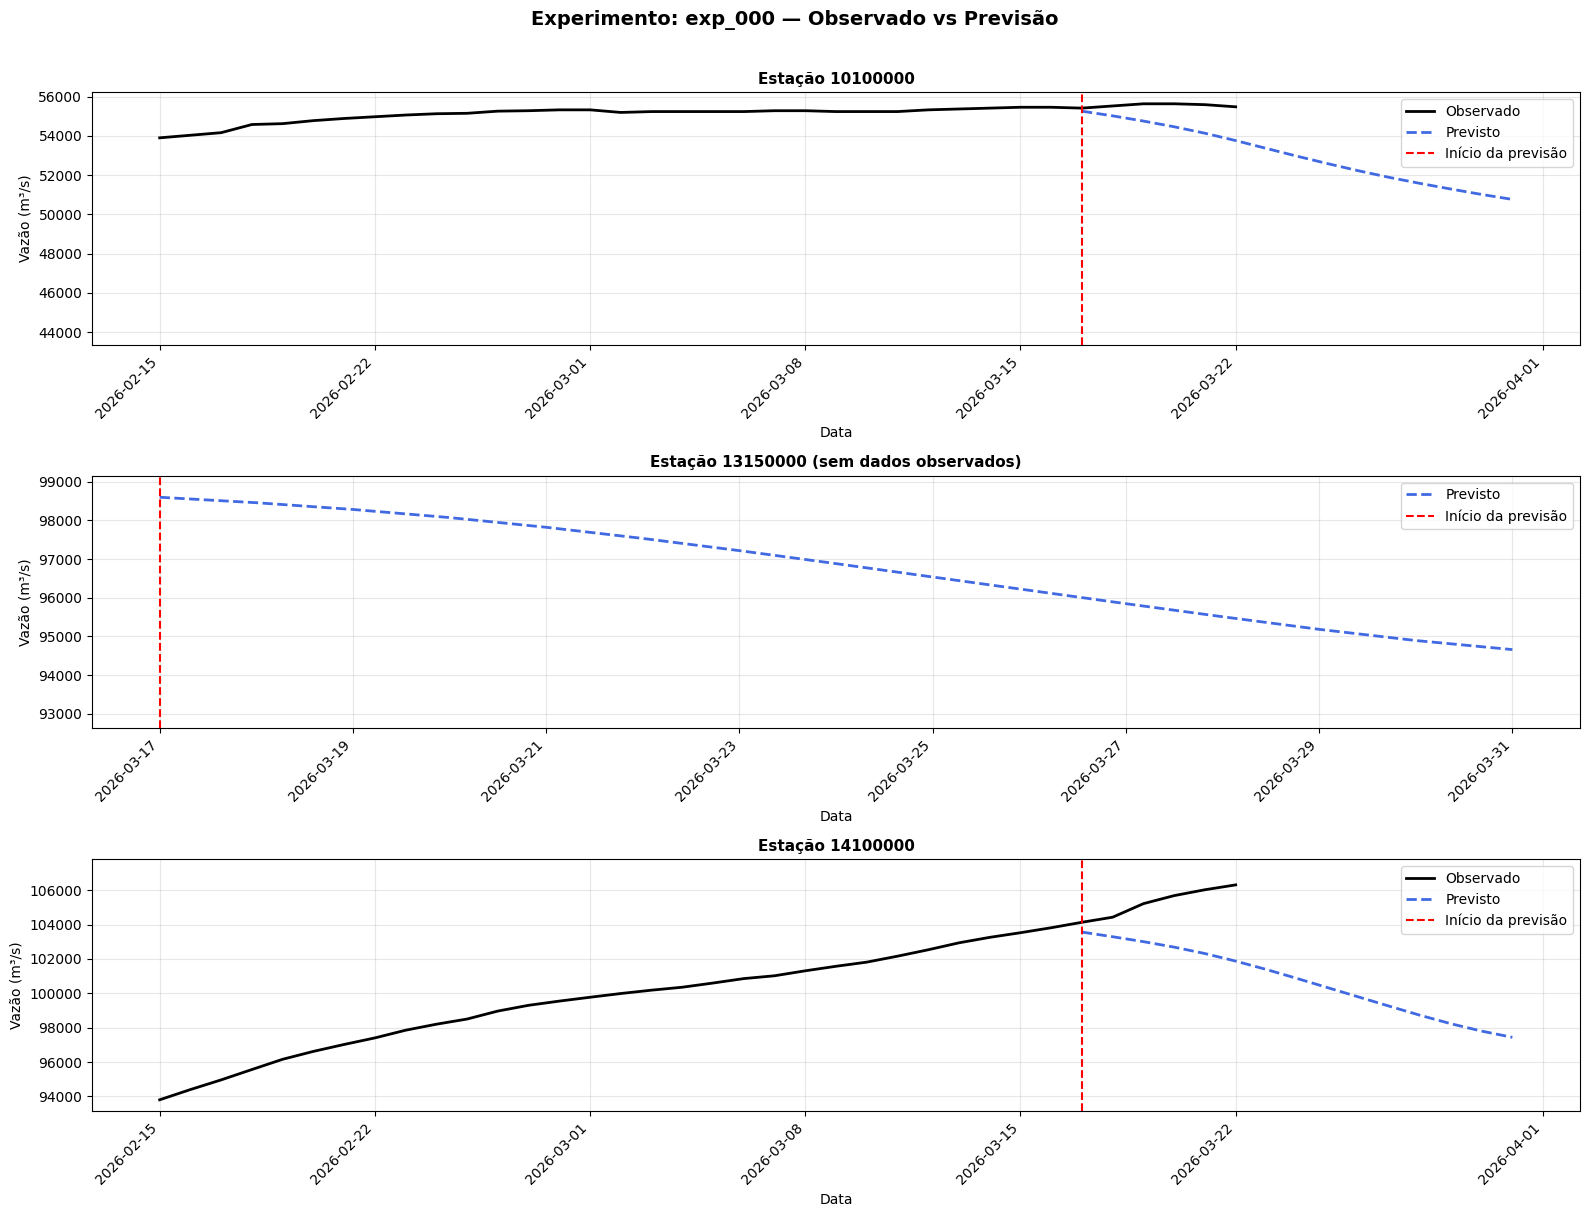

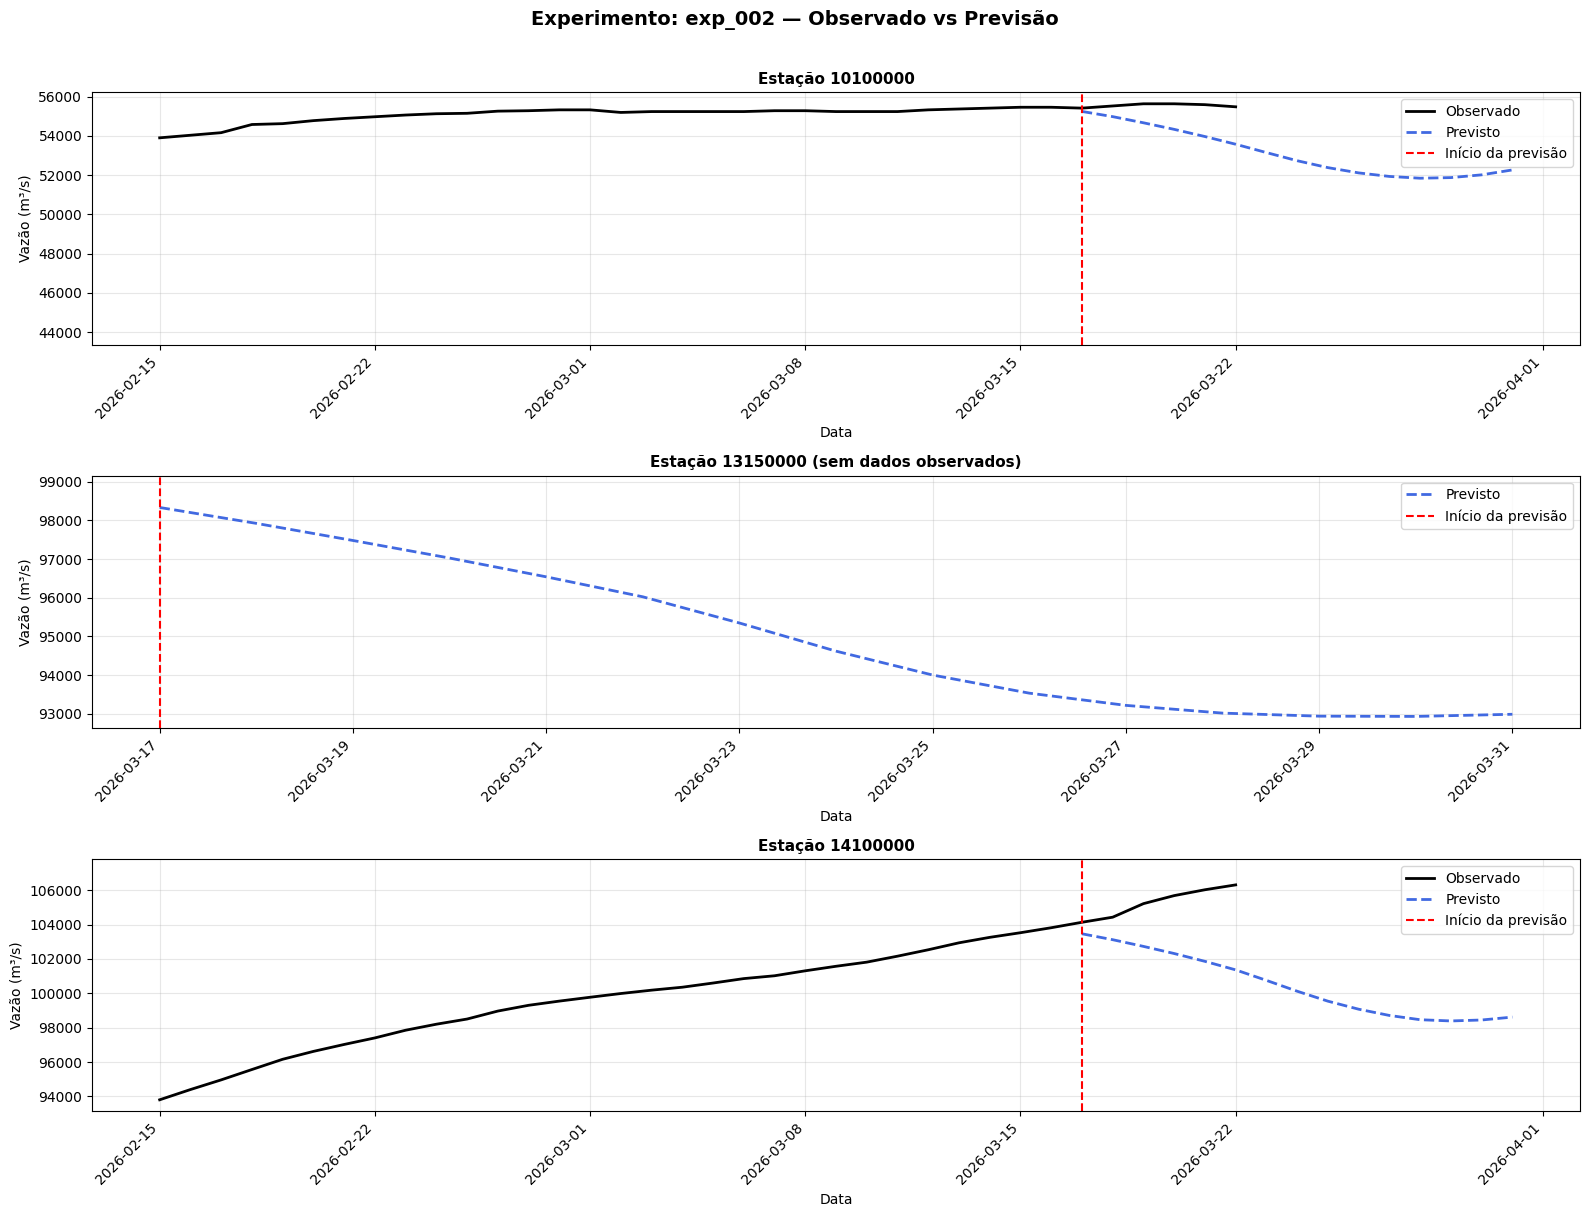

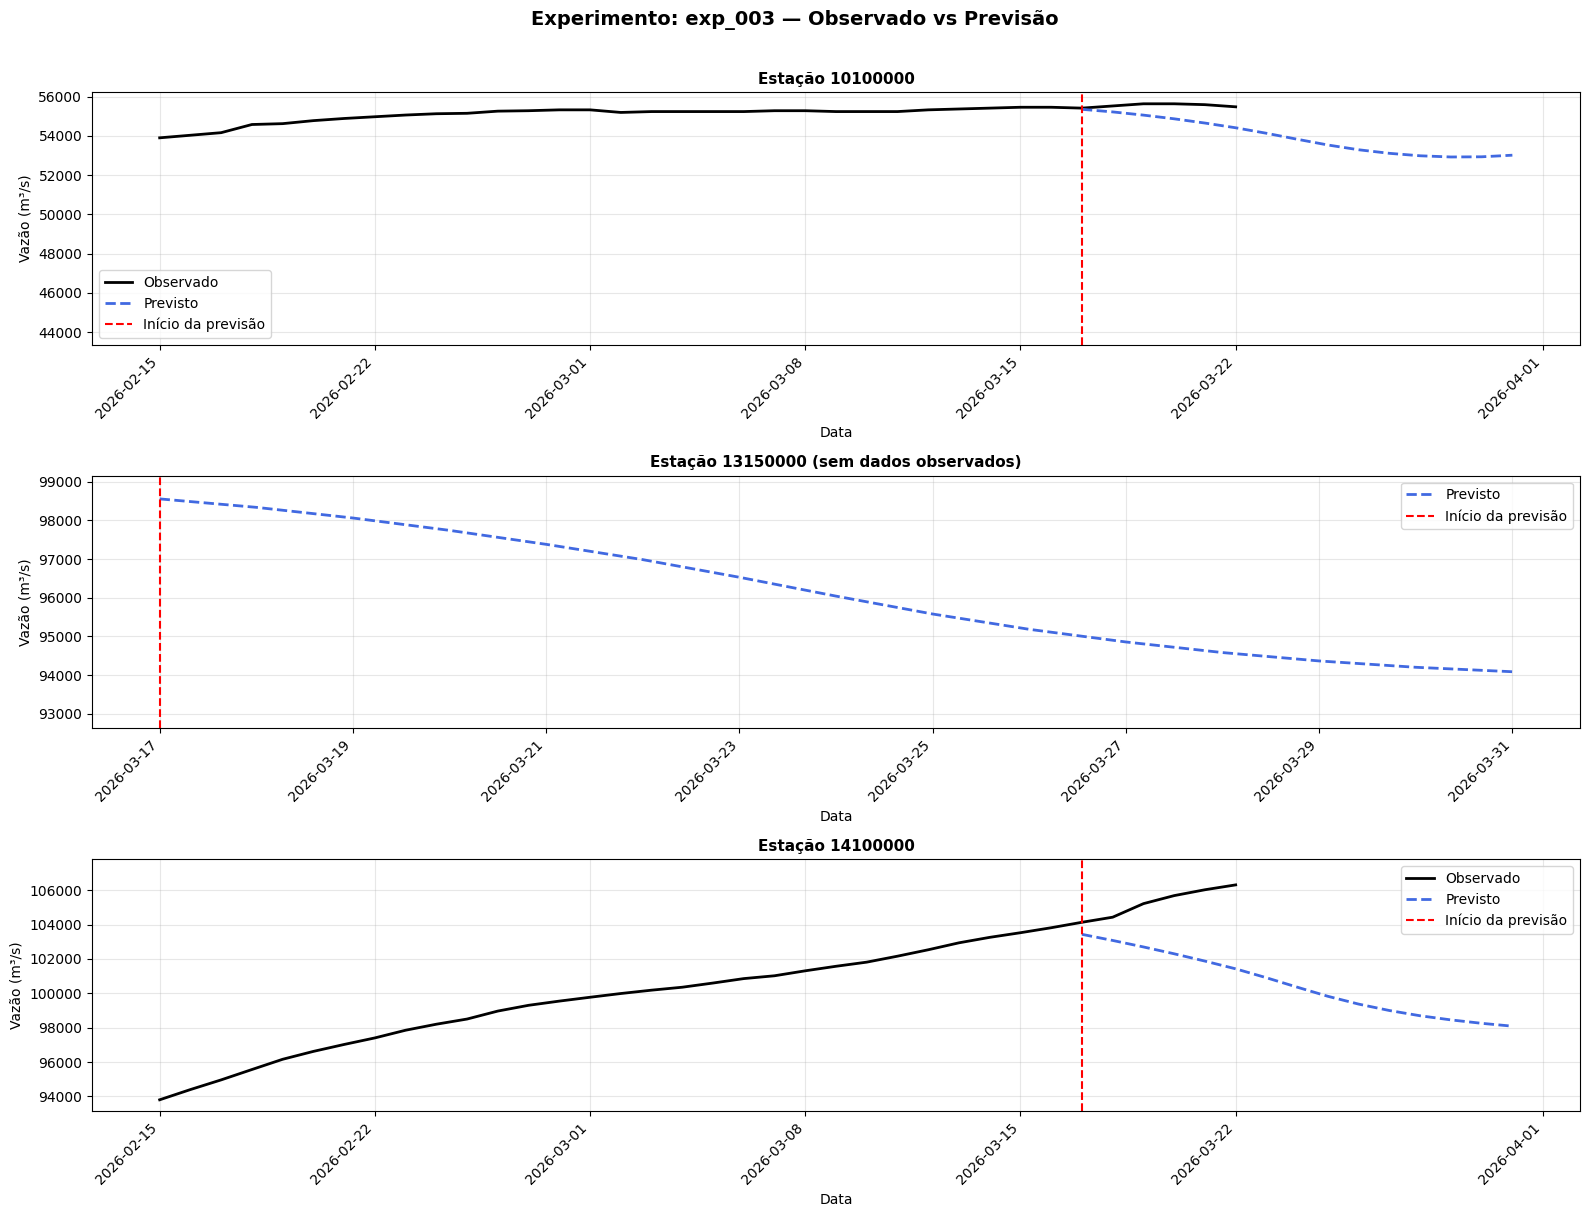

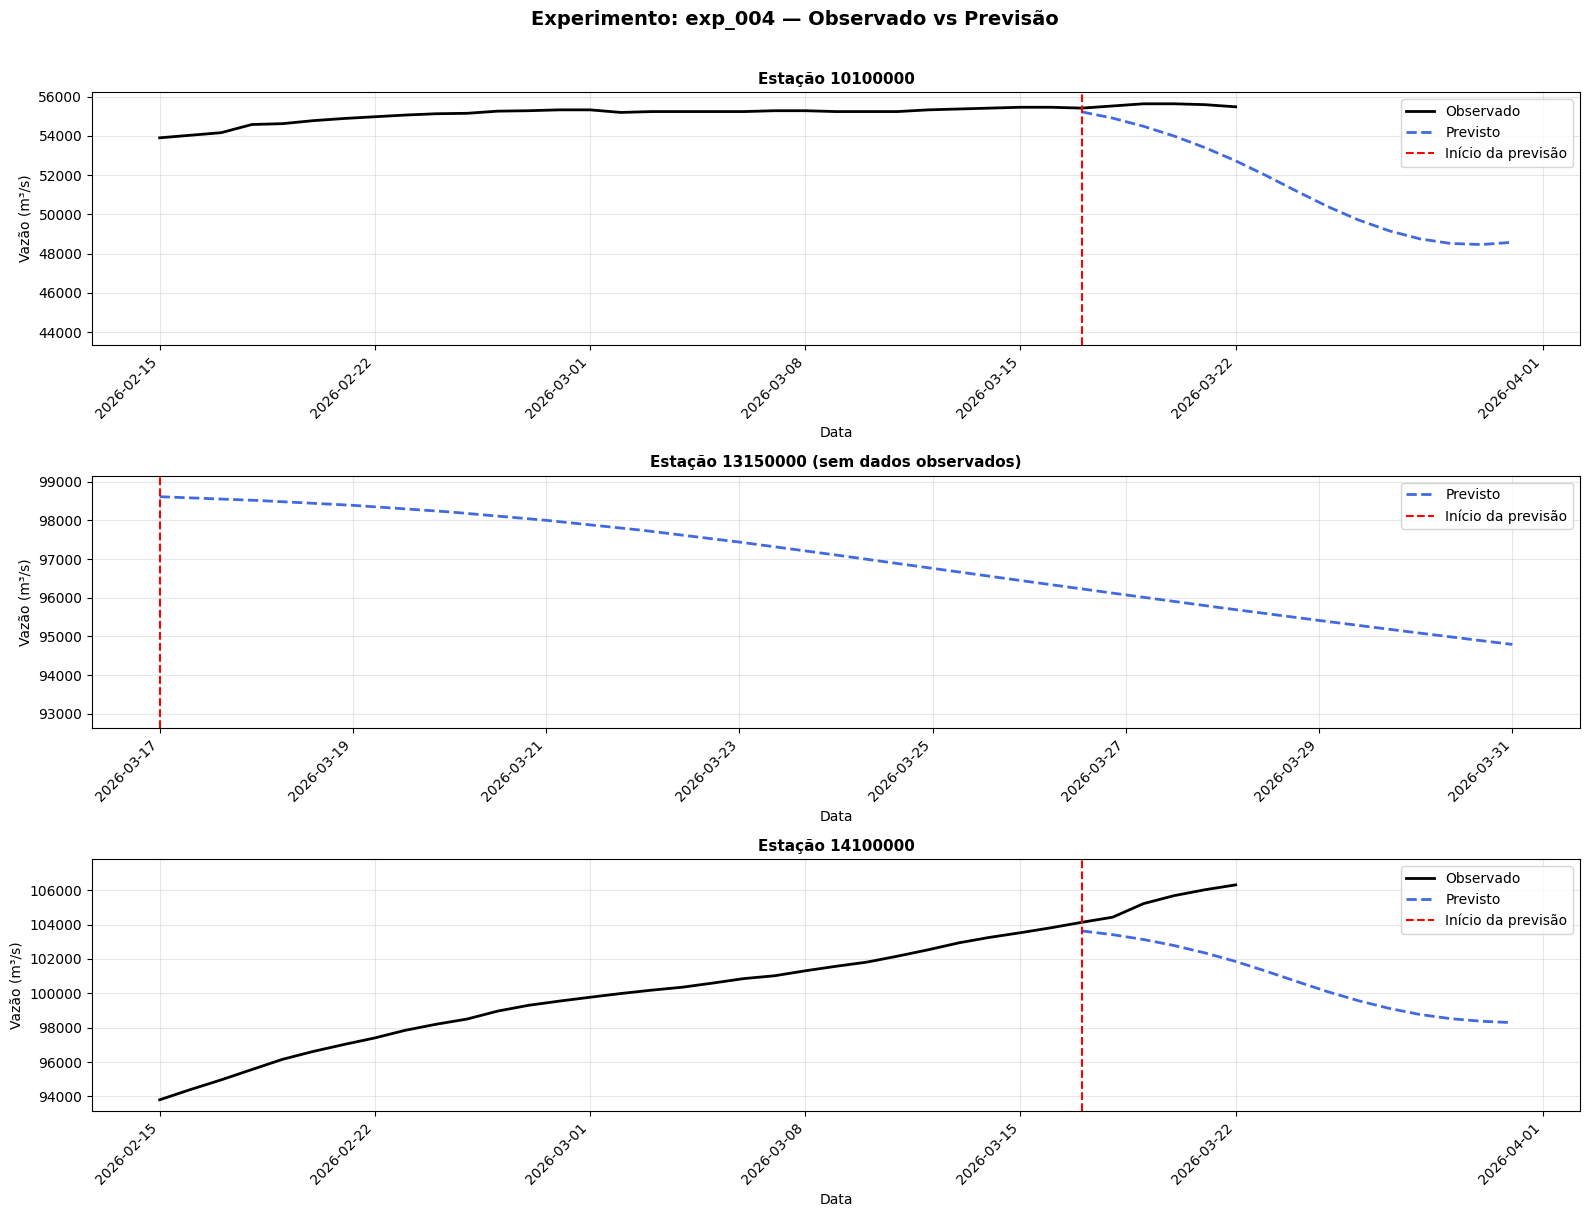

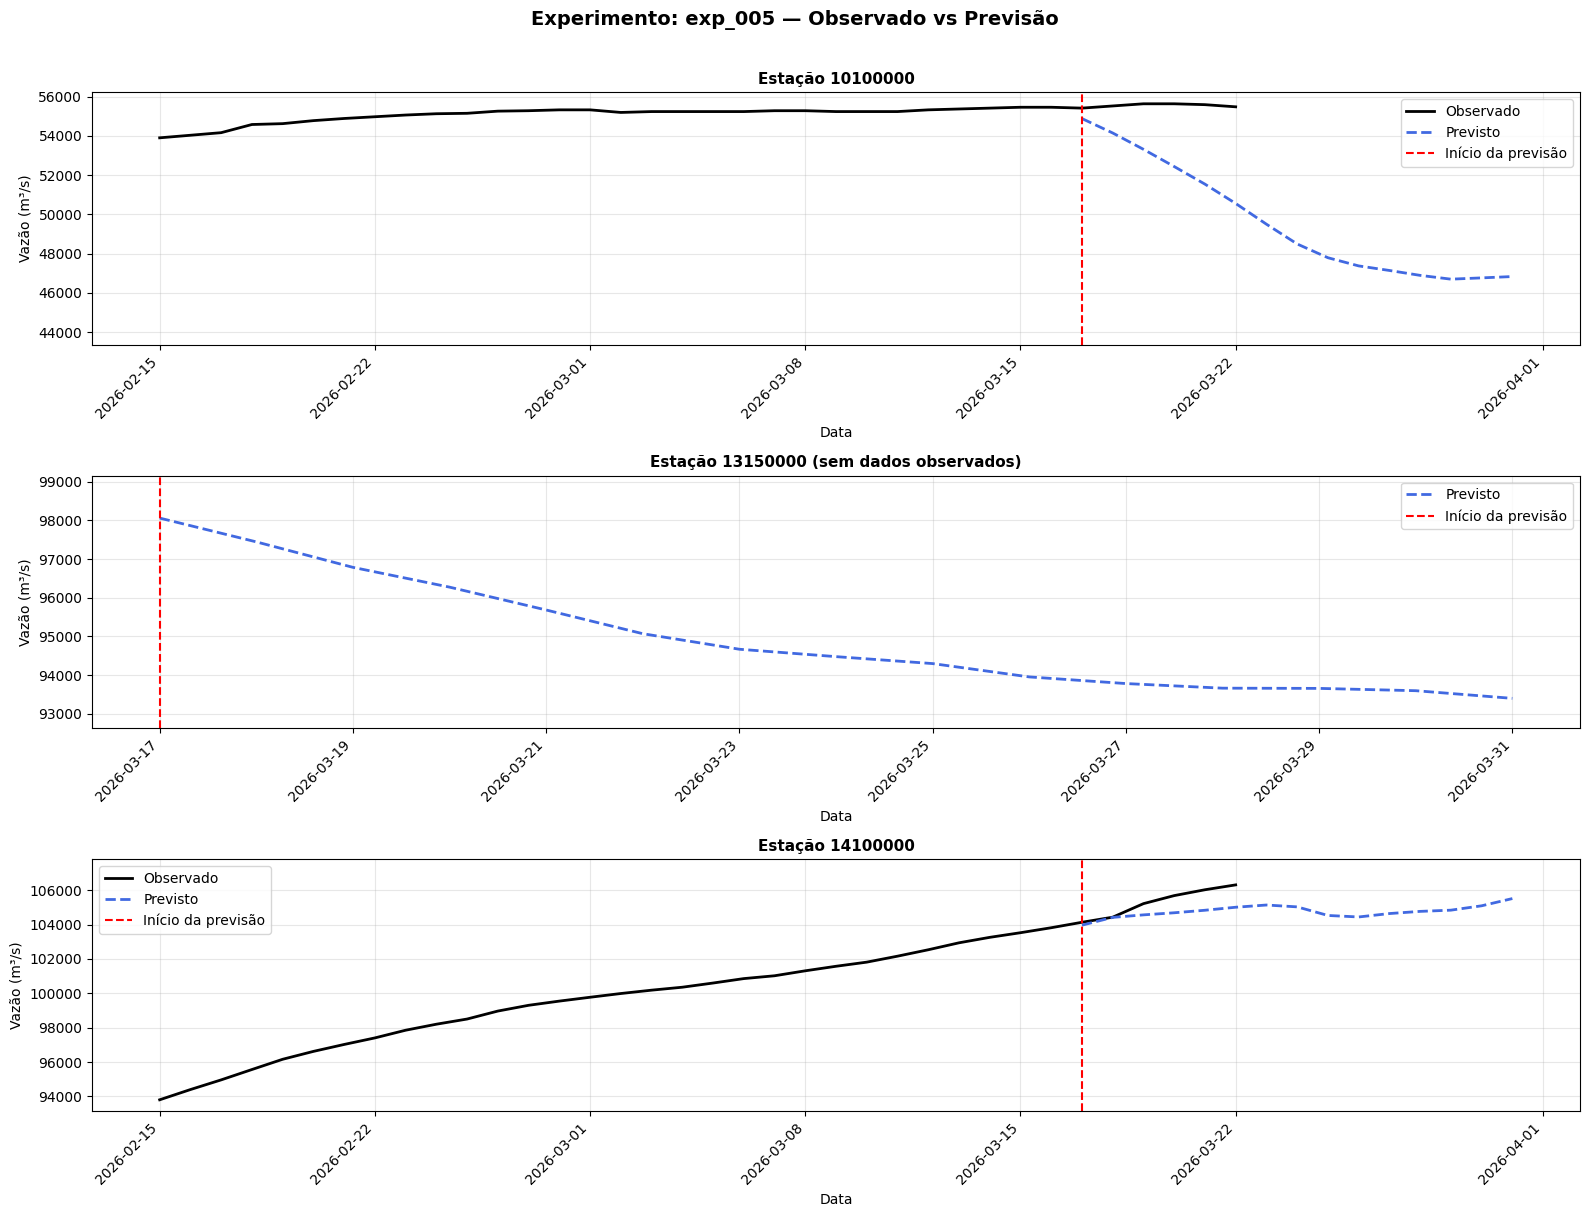

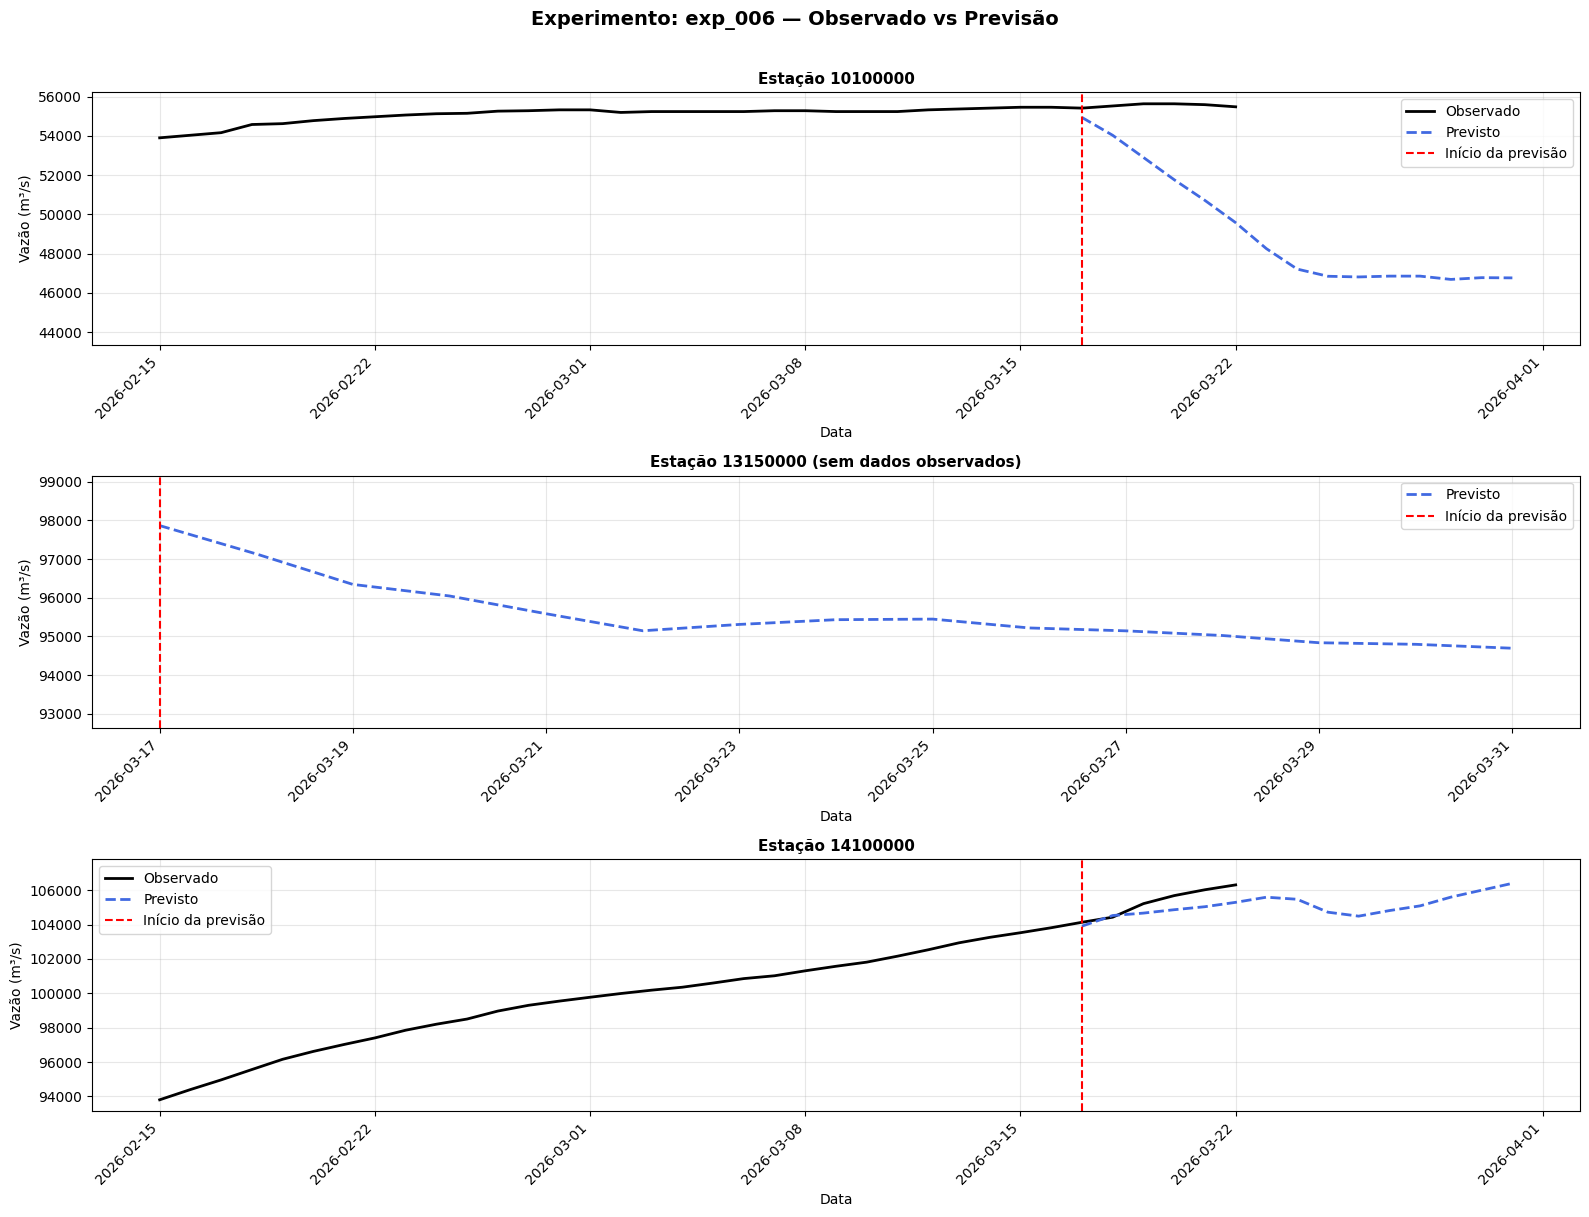

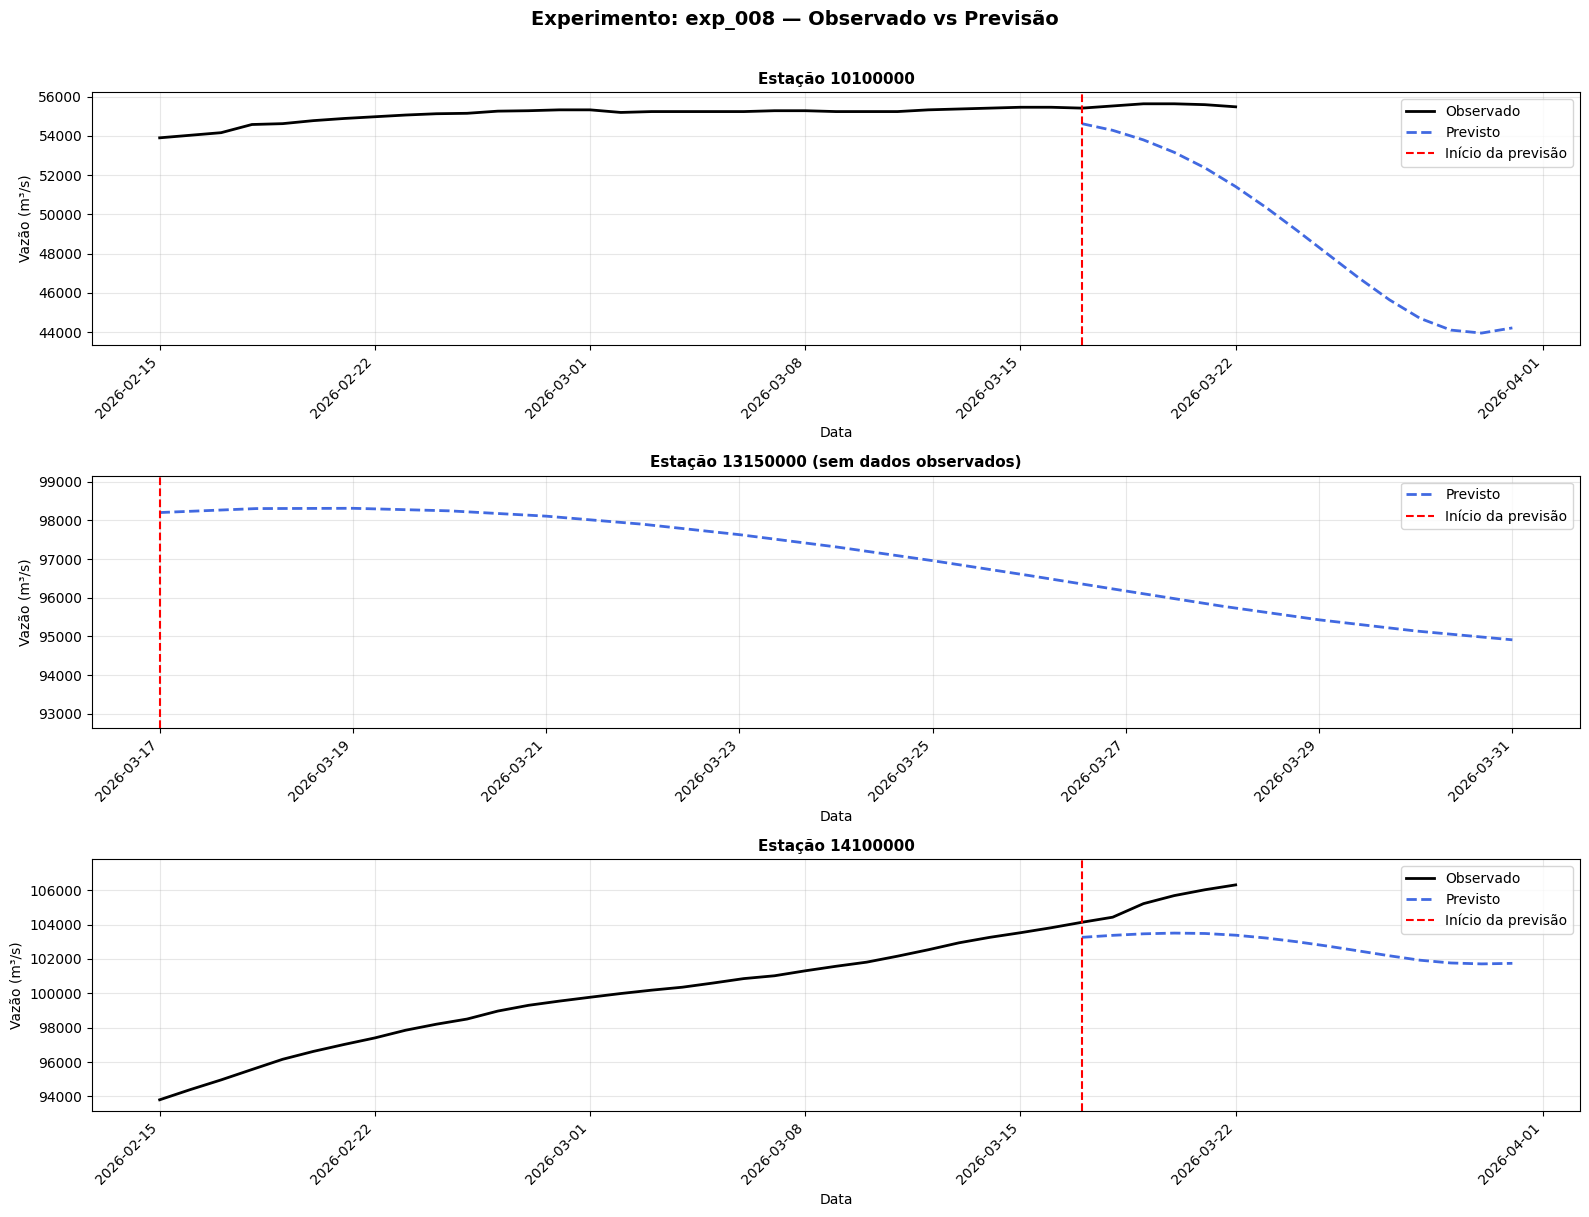

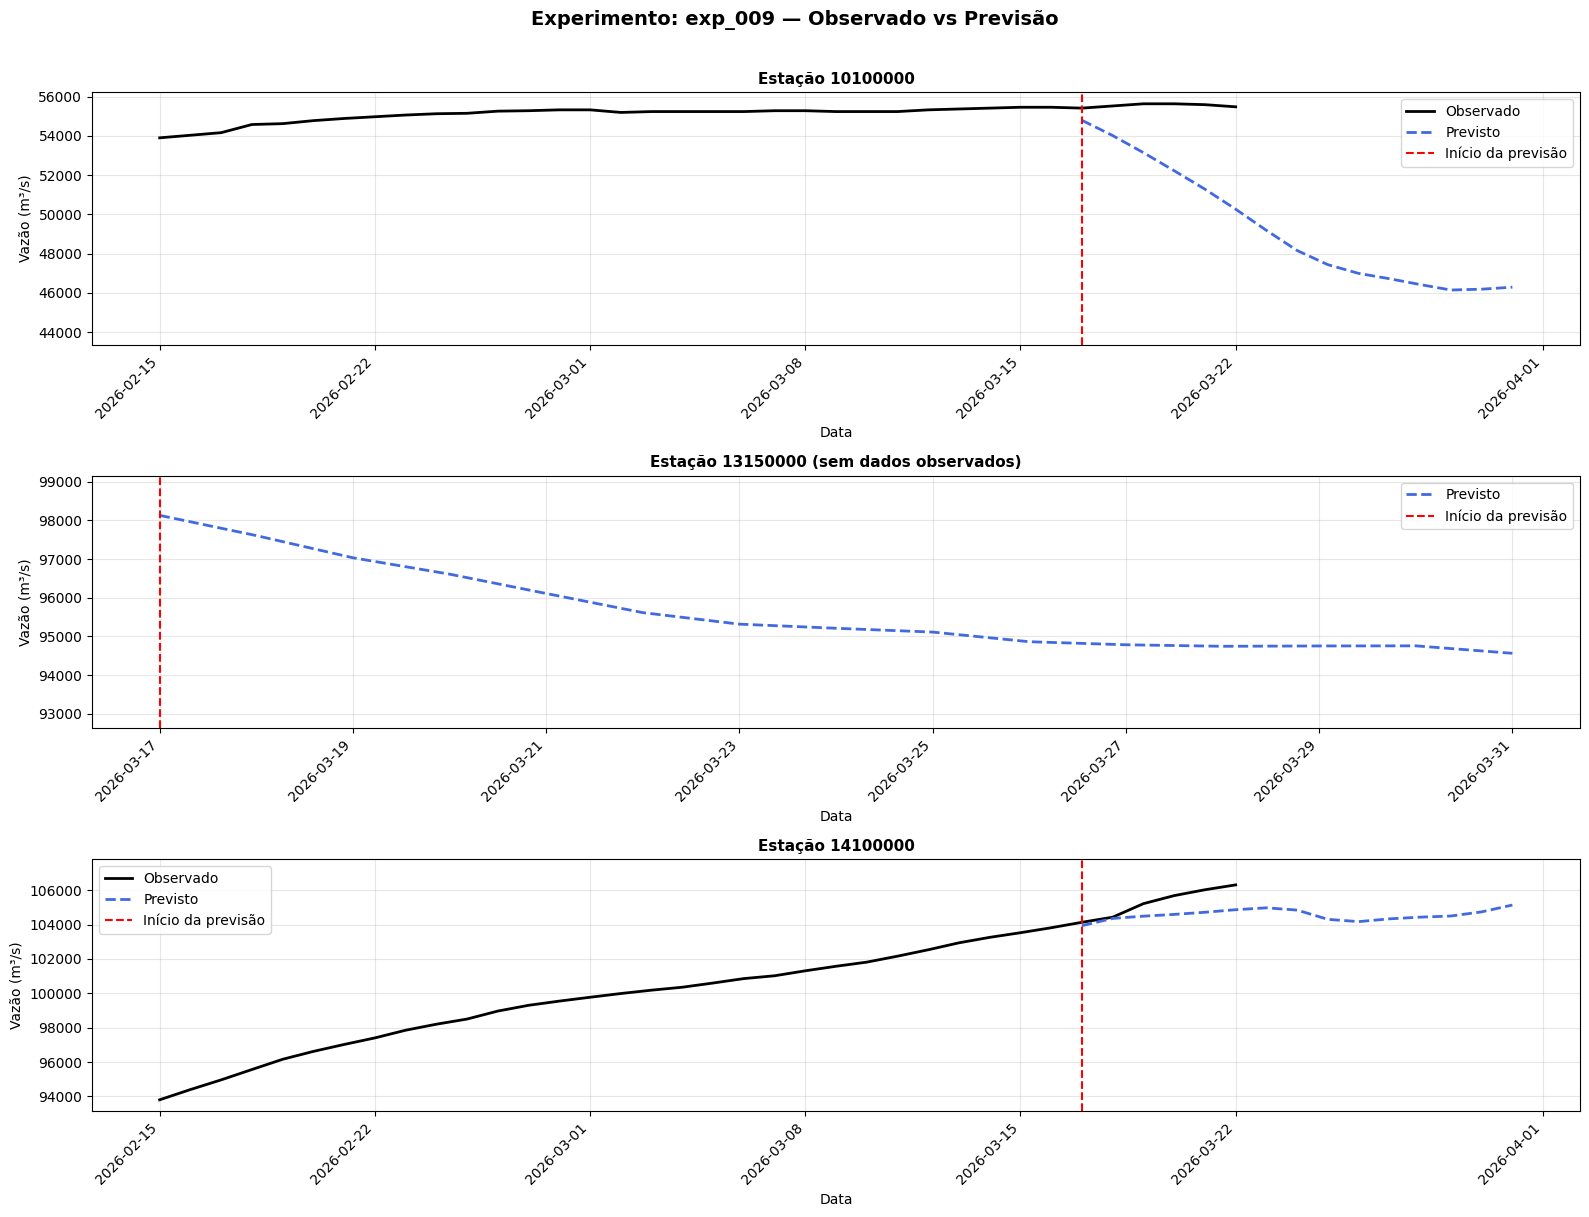

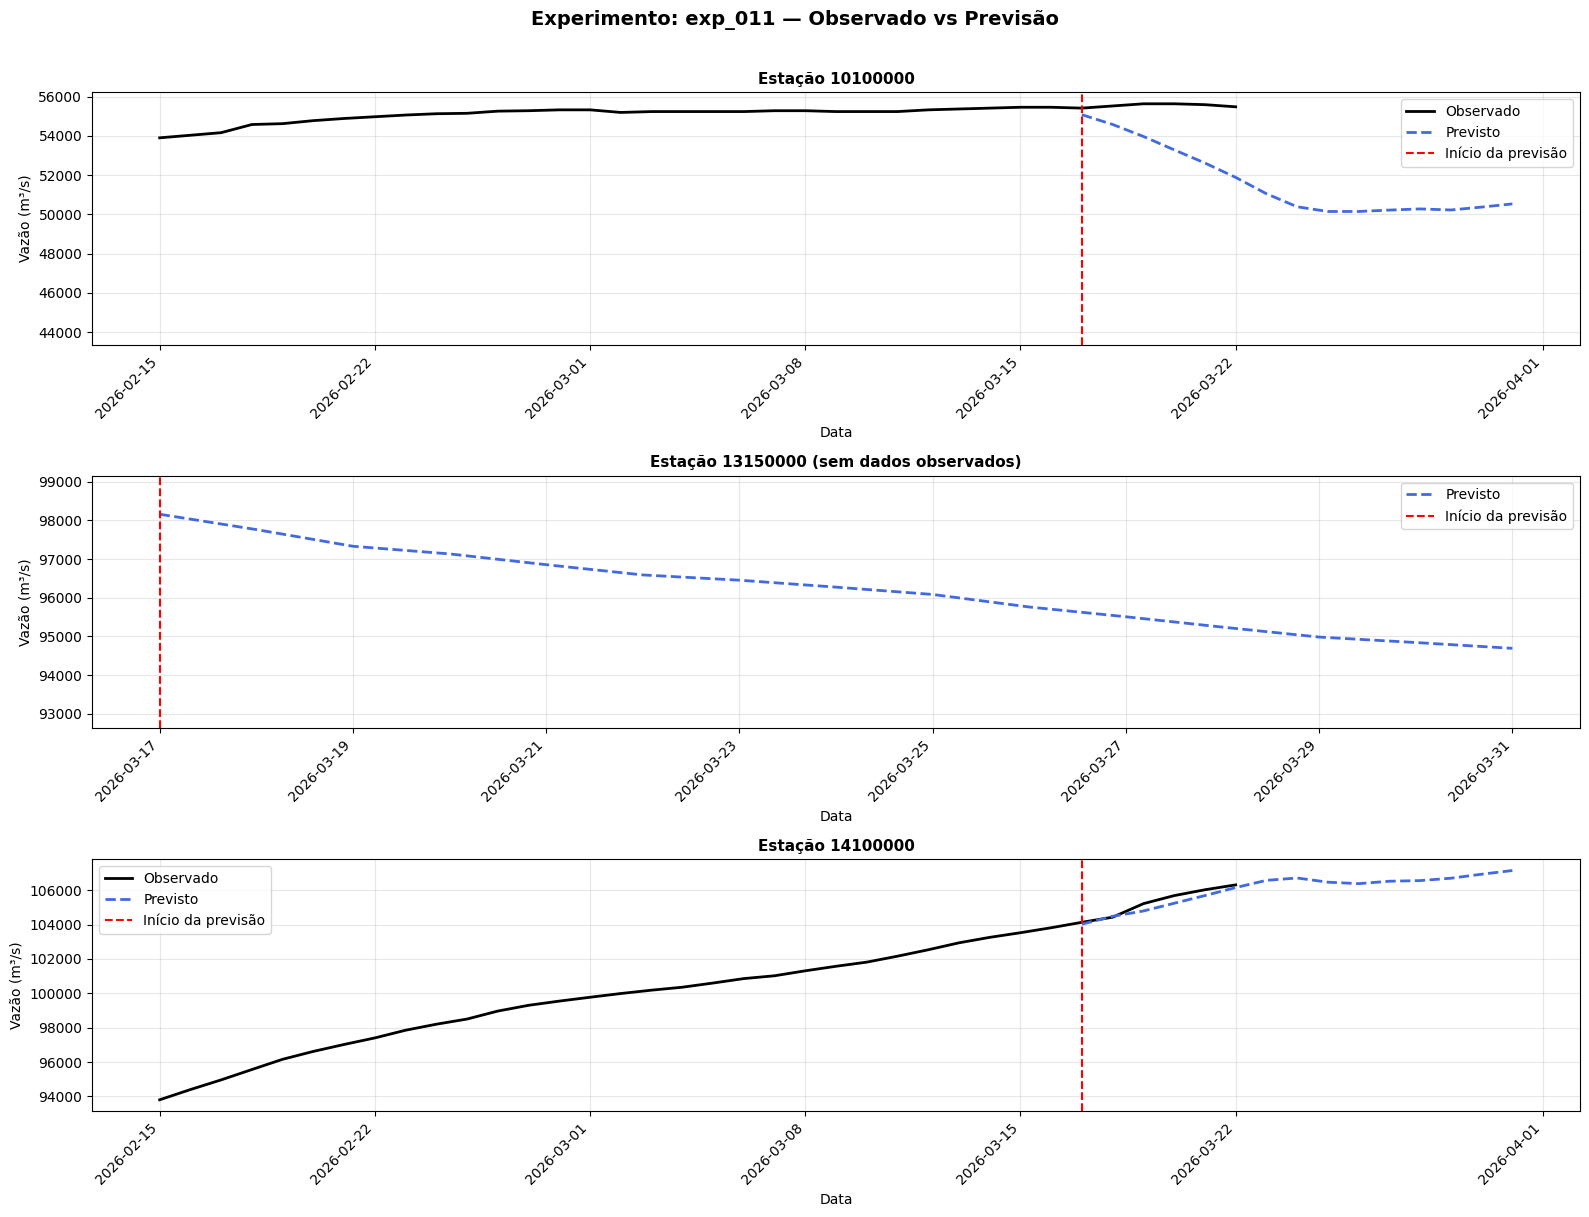

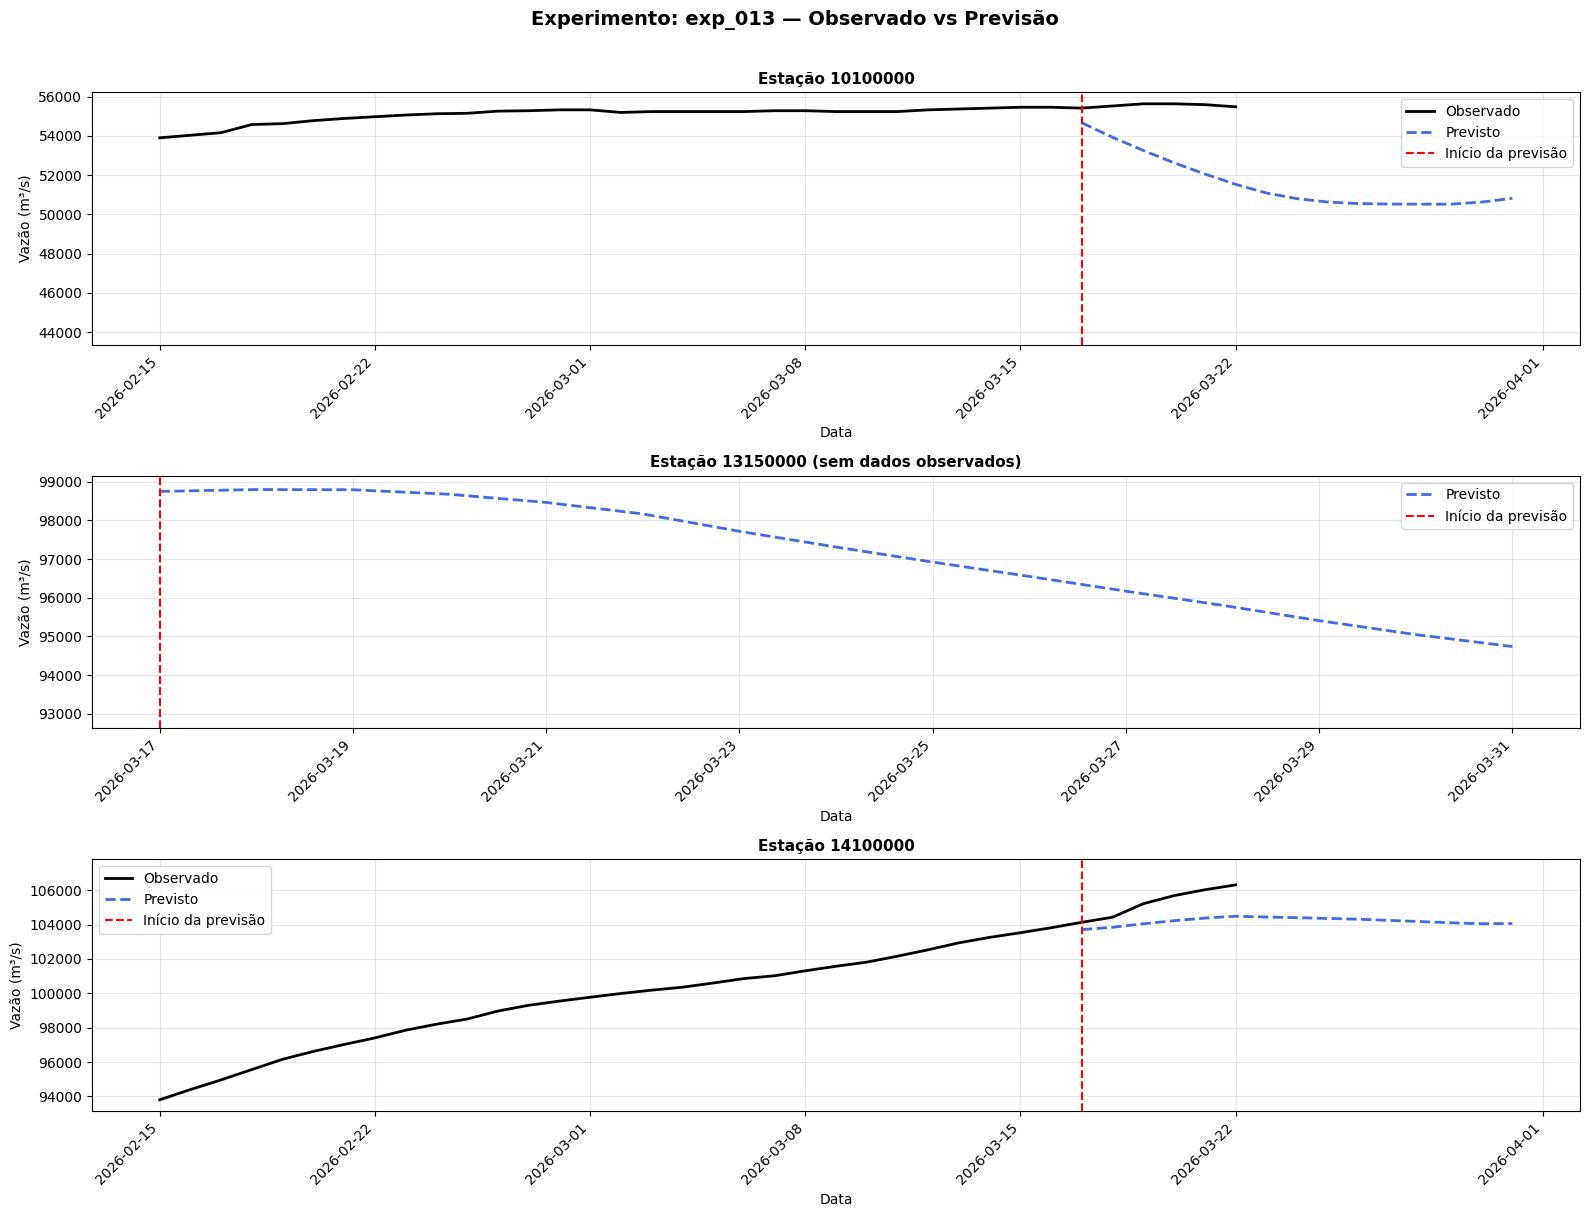

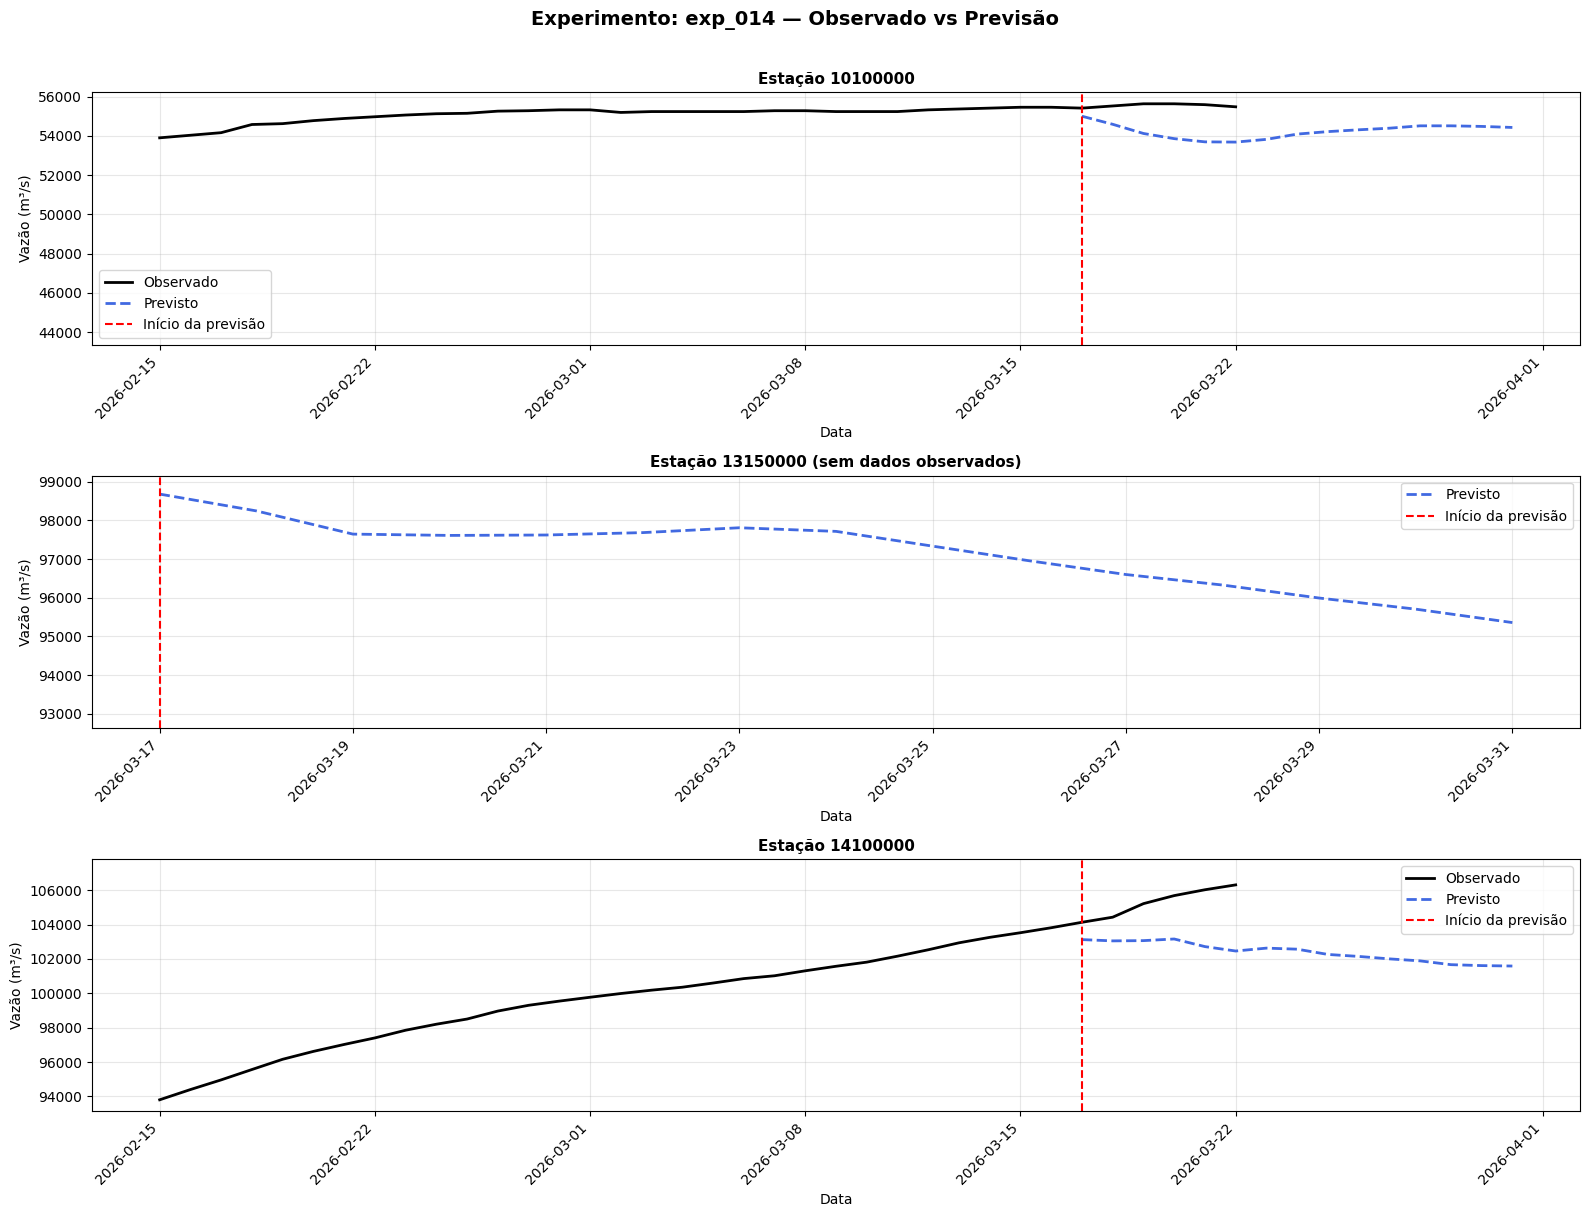

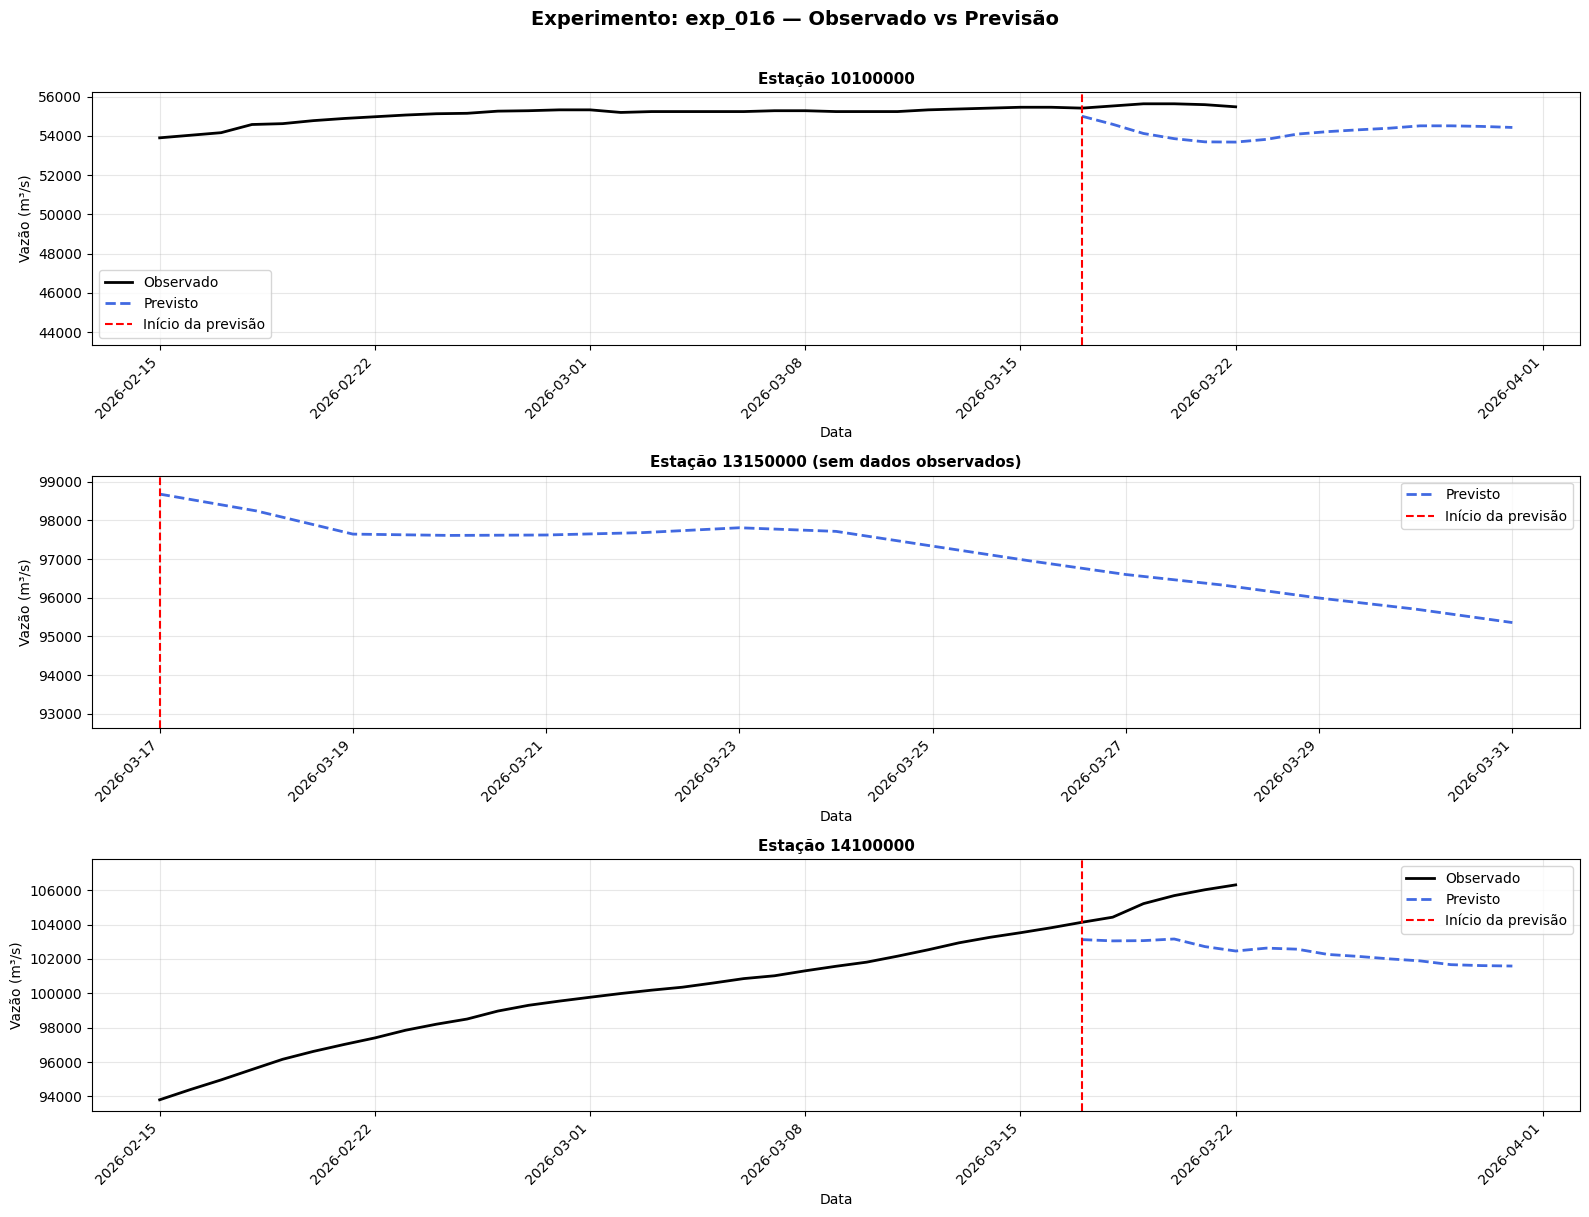

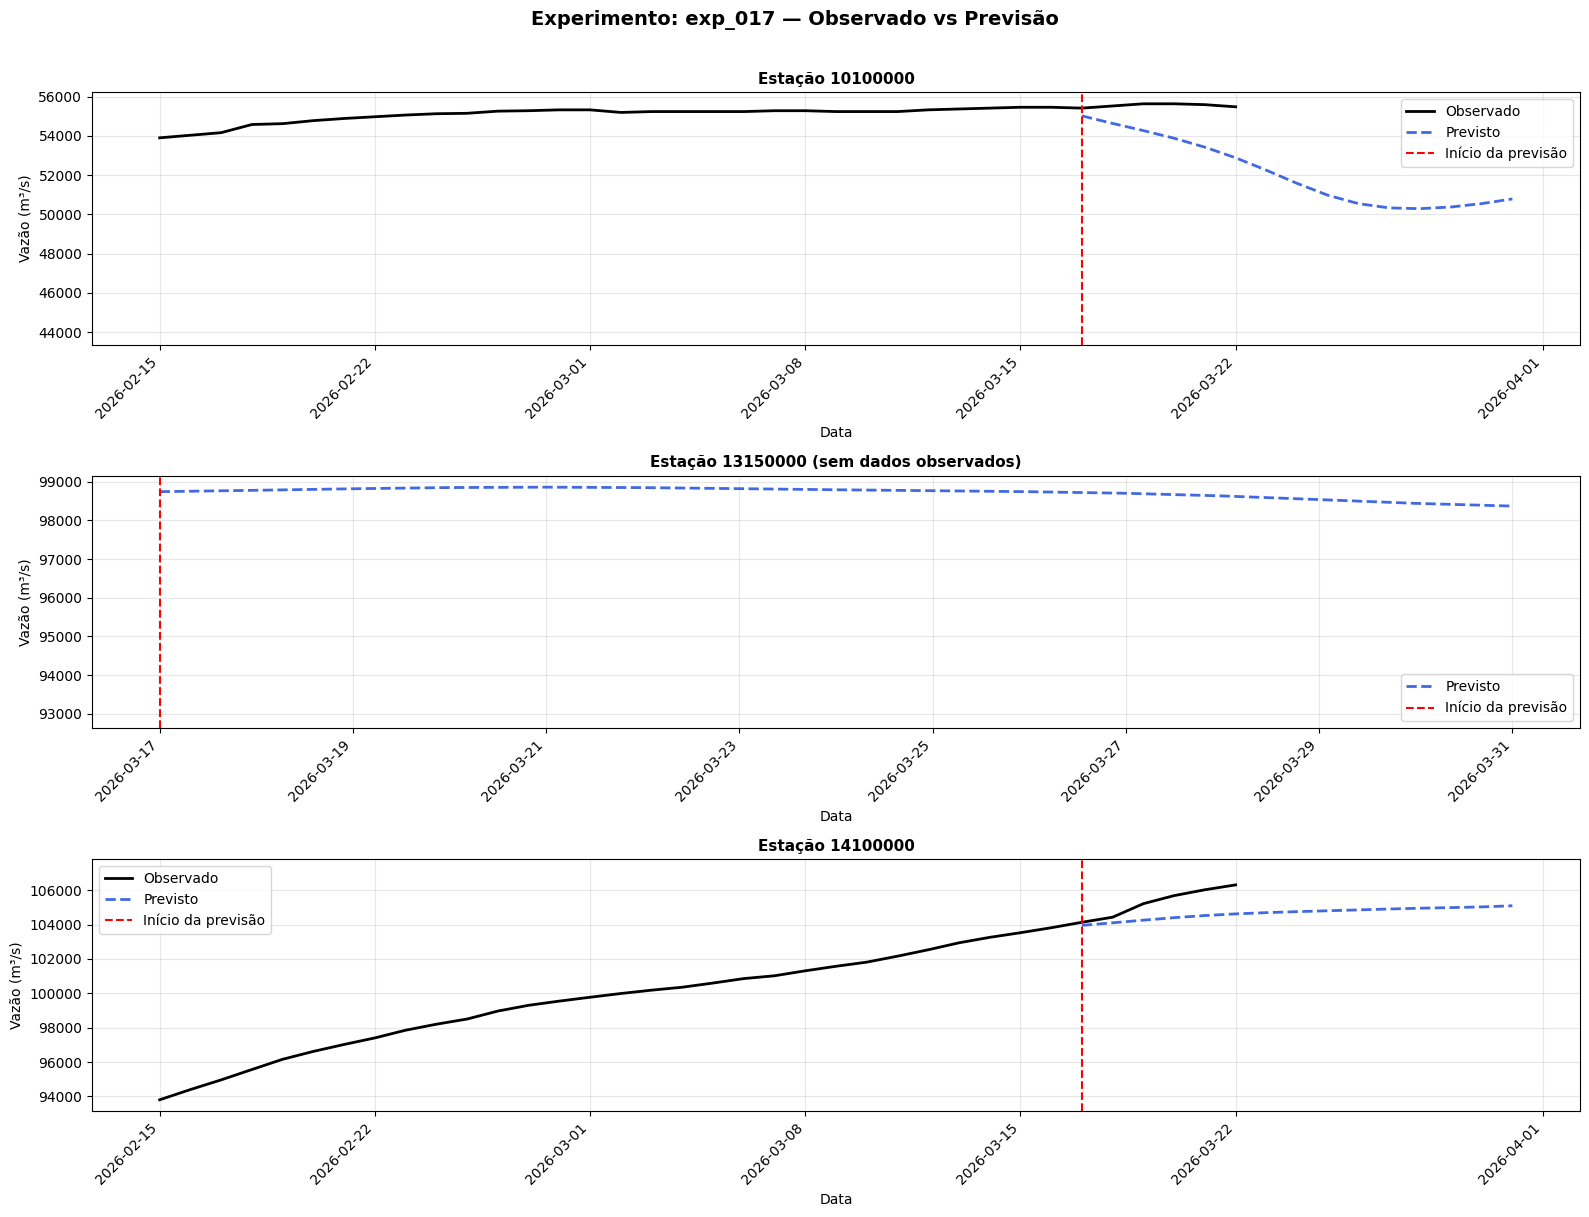

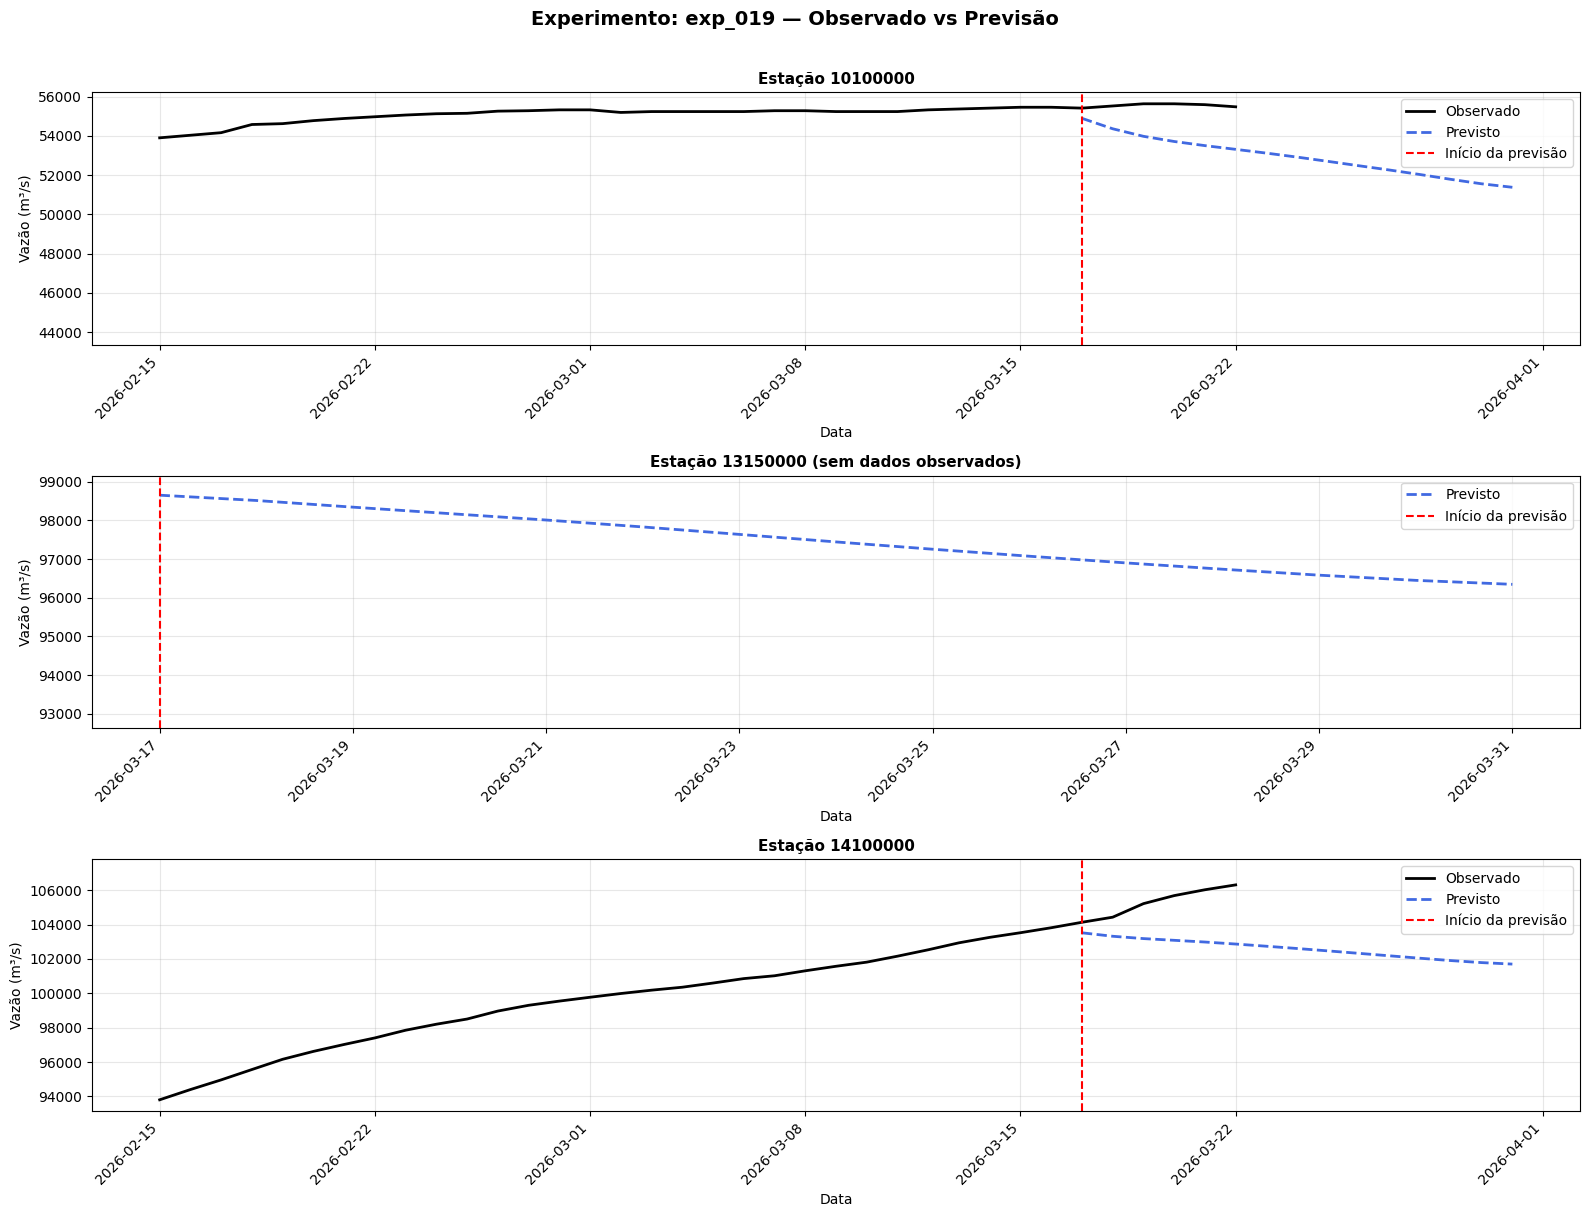

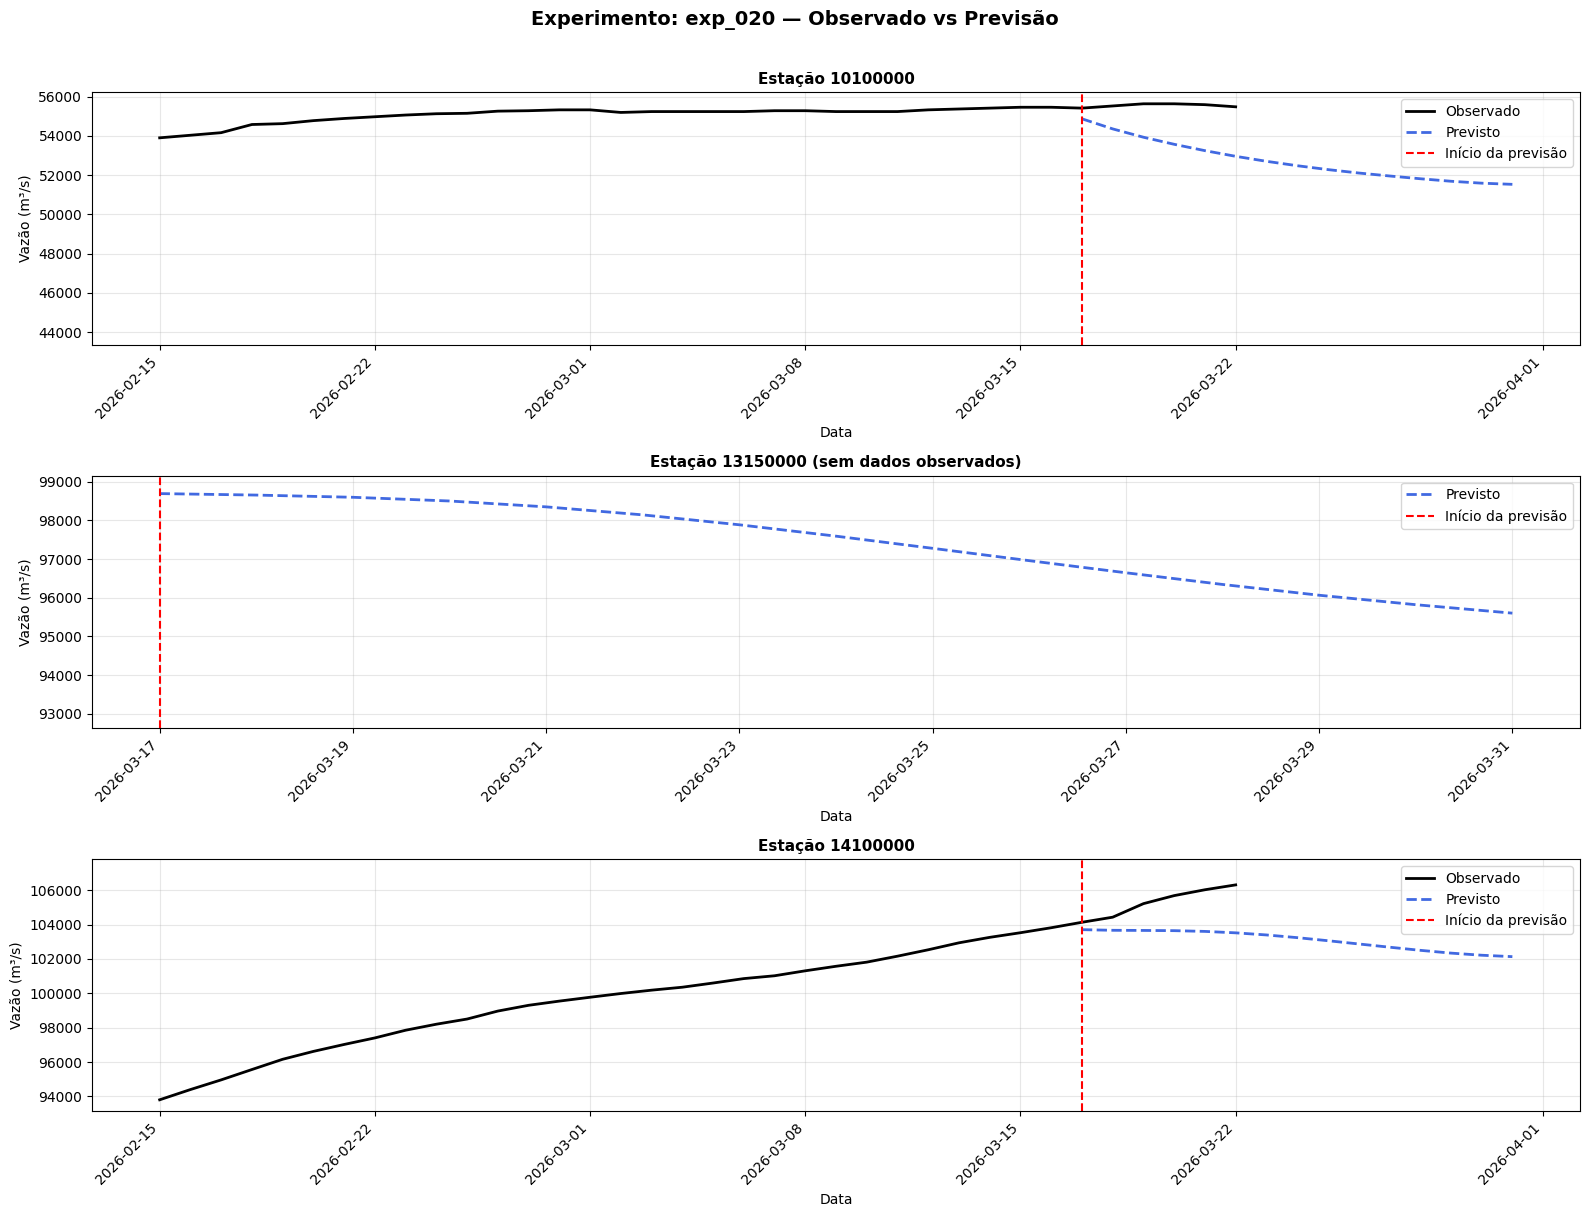

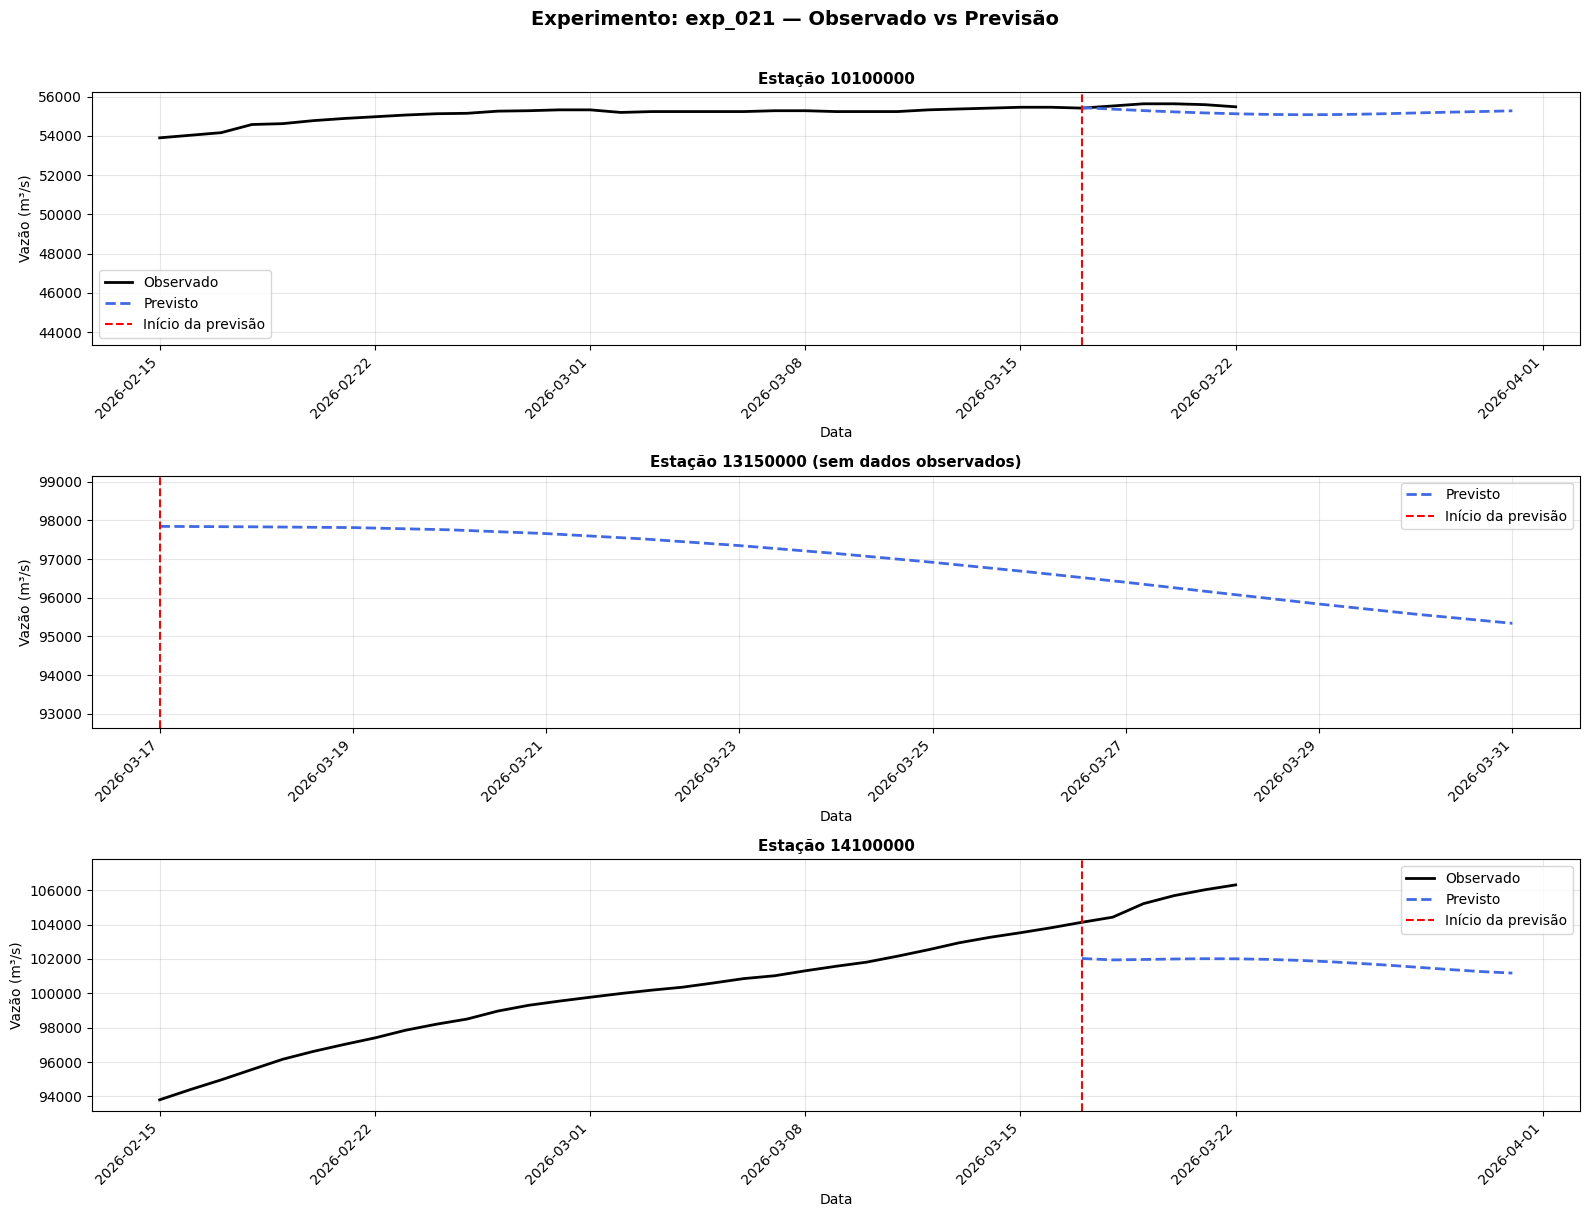

In [7]:
plot_operacional_all_experiments(dados_historicos, experiments, stations)